<center><span style="font-size:35px; font-weight:bold; color:darkblue;">
    DNN
</span></center>

## Import library

In [29]:
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score
import seaborn as sns
import matplotlib.pyplot as plt

## Data Preparation

In [30]:
# Đọc dữ liệu từ CSV
df = pd.read_csv("data_preprocessed/data_features_m01.csv")

# Tách cột đặc trưng và nhãn
X = df.drop('label', axis=1)
y = df['label']

# Chuẩn hóa bằng StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Encode emotion labels as integers
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Train/test split 
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

In [31]:
# Declare the path to save the model
MODEL_DIR = "models"
os.makedirs(MODEL_DIR, exist_ok=True)

BEST_MODEL_PATH = os.path.join(MODEL_DIR, "best_dnn_model_m01.h5")

checkpoint = ModelCheckpoint(
    filepath=BEST_MODEL_PATH,
    monitor="val_macro_f1",
    save_best_only=True,
    save_weights_only=False,
    mode="max",
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_macro_f1",
    patience=10,
    mode="max",
    restore_best_weights=True,
    verbose=1
)

lr_scheduler = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    verbose=1
)

callbacks = [checkpoint, early_stop, lr_scheduler]

In [32]:
class MacroF1(tf.keras.metrics.Metric):
    def __init__(self, num_classes, name="macro_f1", **kwargs):
        super().__init__(name=name, **kwargs)
        self.num_classes = num_classes

        self.tp = self.add_weight(
            name="tp",
            shape=(num_classes,),
            initializer="zeros"
        )
        self.fp = self.add_weight(
            name="fp",
            shape=(num_classes,),
            initializer="zeros"
        )
        self.fn = self.add_weight(
            name="fn",
            shape=(num_classes,),
            initializer="zeros"
        )

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_pred = tf.argmax(y_pred, axis=1, output_type=tf.int32)

        for i in range(self.num_classes):
            y_true_i = tf.equal(y_true, i)
            y_pred_i = tf.equal(y_pred, i)

            tp_i = tf.reduce_sum(tf.cast(tf.logical_and(y_true_i, y_pred_i), tf.float32))
            fp_i = tf.reduce_sum(tf.cast(tf.logical_and(tf.logical_not(y_true_i), y_pred_i), tf.float32))
            fn_i = tf.reduce_sum(tf.cast(tf.logical_and(y_true_i, tf.logical_not(y_pred_i)), tf.float32))

            self.tp.assign(tf.tensor_scatter_nd_add(self.tp, [[i]], [tp_i]))
            self.fp.assign(tf.tensor_scatter_nd_add(self.fp, [[i]], [fp_i]))
            self.fn.assign(tf.tensor_scatter_nd_add(self.fn, [[i]], [fn_i]))

    def result(self):
        precision = self.tp / (self.tp + self.fp + tf.keras.backend.epsilon())
        recall = self.tp / (self.tp + self.fn + tf.keras.backend.epsilon())

        f1 = 2 * precision * recall / (precision + recall + tf.keras.backend.epsilon())

        return tf.reduce_mean(f1)

    def reset_state(self):
        self.tp.assign(tf.zeros_like(self.tp))
        self.fp.assign(tf.zeros_like(self.fp))
        self.fn.assign(tf.zeros_like(self.fn))

    def get_config(self):
        config = super().get_config()
        config.update({
            "num_classes": self.num_classes
        })
        return config

In [33]:
NUM_CLASSES = len(set(y_train))
print("Number of classes:", NUM_CLASSES)

Number of classes: 5


## Build model

In [34]:
# Xây dựng mô hình DNN
model = Sequential([
    Input(shape=(X.shape[1],)),

    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),

    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(len(le.classes_), activation='softmax')
])

# Compile mô hình
model.compile(
    optimizer=Adam(learning_rate=0.0005),  
    loss='sparse_categorical_crossentropy',
    metrics=[
        "accuracy",
        MacroF1(num_classes=NUM_CLASSES)
    ]
)

model.summary()


Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_8 (Dense)             (None, 512)               20992     
                                                                 
 batch_normalization_4 (Bat  (None, 512)               2048      
 chNormalization)                                                
                                                                 
 dropout_6 (Dropout)         (None, 512)               0         
                                                                 
 dense_9 (Dense)             (None, 256)               131328    
                                                                 
 batch_normalization_5 (Bat  (None, 256)               1024      
 chNormalization)                                                
                                                                 
 dropout_7 (Dropout)         (None, 256)              

## Train model

In [35]:
# Early Stopping
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    mode='max',
    restore_best_weights=True,
    verbose=1
)

# Giảm learning rate khi val_loss không cải thiện
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    verbose=1
)

# Lưu best model ra file .h5
checkpoint = ModelCheckpoint(
    filepath=BEST_MODEL_PATH,
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=False,
    mode='max',
    verbose=1
)

# Gộp tất cả callback
callbacks = [checkpoint, early_stop, lr_scheduler]

history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

print("Best model saved at:", BEST_MODEL_PATH)
print("File exists:", os.path.exists(BEST_MODEL_PATH))

Epoch 1/100
95/98 [============================>.] - ETA: 0s - loss: 1.7734 - accuracy: 0.3484 - macro_f1: 0.3340  
Epoch 1: val_accuracy improved from -inf to 0.49422, saving model to models\best_dnn_model_m01.h5
98/98 [==============================] - 3s 11ms/step - loss: 1.7700 - accuracy: 0.3495 - macro_f1: 0.3349 - val_loss: 1.3103 - val_accuracy: 0.4942 - val_macro_f1: 0.4431 - lr: 5.0000e-04
Epoch 2/100
25/98 [======>.......................] - ETA: 0s - loss: 1.4269 - accuracy: 0.4588 - macro_f1: 0.4367

D:\ANACONDA\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


96/98 [============================>.] - ETA: 0s - loss: 1.3582 - accuracy: 0.4759 - macro_f1: 0.4538
Epoch 2: val_accuracy improved from 0.49422 to 0.55202, saving model to models\best_dnn_model_m01.h5
98/98 [==============================] - 1s 6ms/step - loss: 1.3562 - accuracy: 0.4768 - macro_f1: 0.4545 - val_loss: 1.1062 - val_accuracy: 0.5520 - val_macro_f1: 0.5255 - lr: 5.0000e-04
Epoch 3/100
94/98 [===========================>..] - ETA: 0s - loss: 1.1987 - accuracy: 0.5339 - macro_f1: 0.5090
Epoch 3: val_accuracy improved from 0.55202 to 0.61272, saving model to models\best_dnn_model_m01.h5
98/98 [==============================] - 1s 7ms/step - loss: 1.1994 - accuracy: 0.5357 - macro_f1: 0.5101 - val_loss: 0.9465 - val_accuracy: 0.6127 - val_macro_f1: 0.6036 - lr: 5.0000e-04
Epoch 4/100
98/98 [==============================] - ETA: 0s - loss: 1.0916 - accuracy: 0.5711 - macro_f1: 0.5515
Epoch 4: val_accuracy improved from 0.61272 to 0.71387, saving model to models\best_dnn_mode

## Predict on test set

In [36]:
# Dự đoán xác suất
y_pred_probs = model.predict(X_test)

# Dự đoán nhãn (class)
y_pred = np.argmax(y_pred_probs, axis=1)


27/27 [==============================] - 0s 2ms/step


## Evaluation

In [37]:
# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_, digits=4))



Classification Report:
              precision    recall  f1-score   support

       angry     0.9392    0.8854    0.9115       192
     disgust     0.8971    0.9531    0.9242       192
        fear     0.9565    0.9167    0.9362       192
     neutral     0.8125    0.9479    0.8750        96
         sad     0.9563    0.9115    0.9333       192

    accuracy                         0.9201       864
   macro avg     0.9123    0.9229    0.9161       864
weighted avg     0.9234    0.9201    0.9206       864



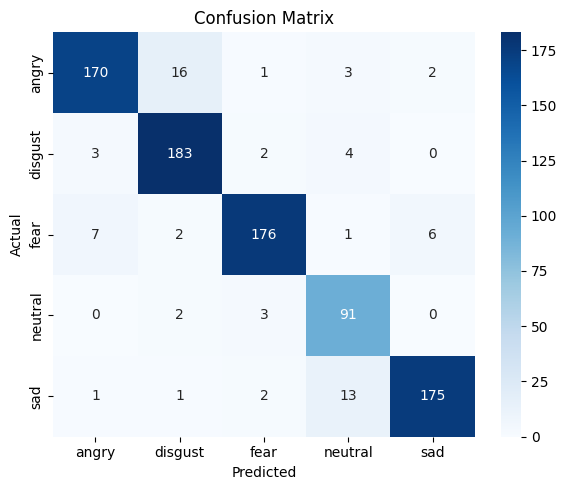

In [38]:
# Confusion Matrix
conf_mat = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_mat, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [39]:
# Cohen’s Kappa
kappa = cohen_kappa_score(y_test, y_pred)
print(f"Cohen's Kappa: {kappa:.4f}")

Cohen's Kappa: 0.8992


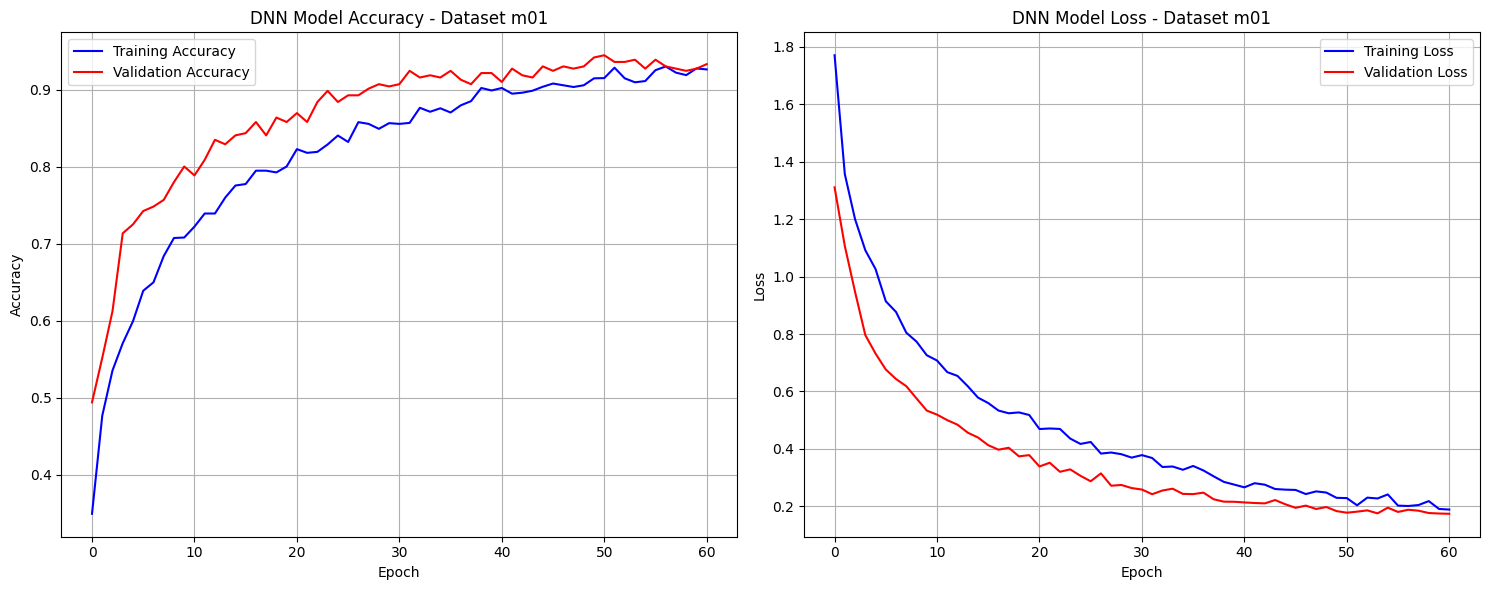

Training history plots generated!


In [40]:
# Plot Training History
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Accuracy plot
ax1.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
ax1.set_title('DNN Model Accuracy - Dataset m01')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss plot
ax2.plot(history.history['loss'], label='Training Loss', color='blue')
ax2.plot(history.history['val_loss'], label='Validation Loss', color='red')
ax2.set_title('DNN Model Loss - Dataset m01')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print("Training history plots generated!")